# VGG19 Baseline Model for Pneumonia Detection
This notebook establishes a performance baseline using a pre-trained VGG19 architecture. We will benchmark our custom CNN's accuracy, recall, and training time against this heavy, industry-standard model.

In [ ]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg19 import VGG19

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
train = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
test = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
val = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'

img = tf.keras.utils.img_to_array(tf.keras.utils.load_img('/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA/person1001_bacteria_2932.jpeg'))
print(img.shape)


(863, 1244, 3)


In [ ]:
class EarlyStopping(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    model.save('/content/model'+str(epoch)+'.keras')
    if(logs['accuracy']>0.99):
      print("\nReached 99% accuracy so cancelling training!")
      self.model.stop_training = True

## Transfer Learning: VGG19 Architecture
Importing the VGG19 base model with pre-trained ImageNet weights. We freeze the base model and attach a custom classification head to adapt it for our binary pneumonia dataset.

In [ ]:
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# 2. Freeze the base model
base_model.trainable = False


model = tf.keras.models.Sequential([
    # Keep your data augmentation from before
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),

    # Add the VGG19 base
    base_model,

    # Flatten and add your custom classification head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'), # Added activation here as it was missing in your snippet
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print(model.summary())
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 4, 4, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,123,073 (84.39 MB)

 Trainable params: 2,098,177 (8.00 MB)

 Non-trainable params: 20,024,896 (76.39 MB)

None


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train,
                image_size=(128, 128),
                batch_size=32,
                label_mode = 'binary')

val_dataset = tf.keras.utils.image_dataset_from_directory(val,
                image_size=(128, 128),
                batch_size=32,
                label_mode = 'binary')

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


## Data Loading & VGG19 Preprocessing
Loading the images and applying VGG19's native `preprocess_input` function to ensure the data is scaled exactly as the base model expects.

In [ ]:
from tensorflow.keras.applications.vgg19 import preprocess_input

# Replace your manual rescale_layer with this
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y))

#configure dataset
train_dataset = (train_dataset
                .cache()
                .shuffle(100)
                .prefetch(buffer_size=tf.data.AUTOTUNE))


val_dataset = (val_dataset
                .cache()
                .shuffle(100)
                .prefetch(buffer_size=tf.data.AUTOTUNE))


## Baseline Model Training
Training the VGG19 benchmark model. (Note the significantly longer epoch training time compared to the custom architecture).

In [ ]:
model.fit(train_dataset, epochs=1, validation_data=val_dataset, verbose= 1, callbacks = [EarlyStopping()])

163/163 ━━━━━━━━━━━━━━━━━━━━ 1327s 8s/step - accuracy: 0.9018 - loss: 0.2382 - val_accuracy: 0.8622 - val_loss: 0.4257


## Baseline Evaluation & Classification Report
Evaluating the VGG19 model's performance to establish the baseline metrics (Precision, Recall, F1-Score) that our custom CNN must compete against.

Generating predictions for the test set...


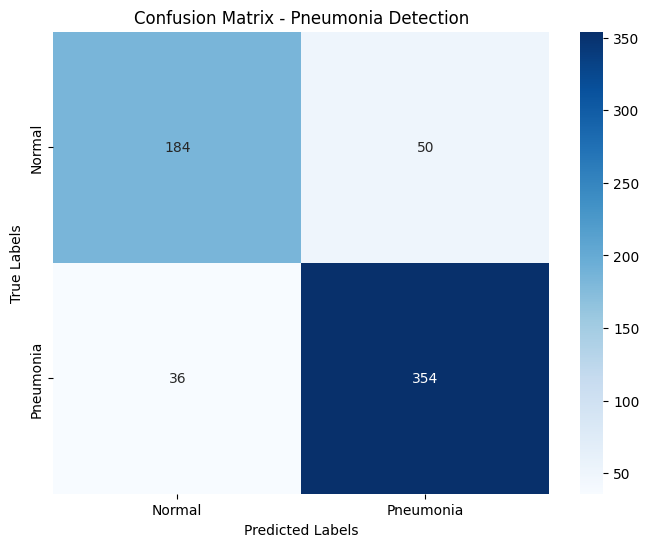


Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.79      0.81       234
   Pneumonia       0.88      0.91      0.89       390

    accuracy                           0.86       624
   macro avg       0.86      0.85      0.85       624
weighted avg       0.86      0.86      0.86       624



In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. Collect all true labels and predictions
y_true = []
y_pred = []

print("Generating predictions for the test set...")
for images, labels in val_dataset:
    # Get predictions (probabilities)
    preds = model.predict(images, verbose=0)

    # Convert probabilities to binary labels (0 or 1)
    # Using 0.5 as threshold (consistent with your manual testing code)
    pred_labels = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()

# 2. Calculate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Pneumonia Detection')
plt.show()

# 4. Print Classification Report for Precision, Recall, and F1-score
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))